In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from q3dfit.q3din import q3din
from q3dfit.q3dutil import get_q3dio

202.80170236058947

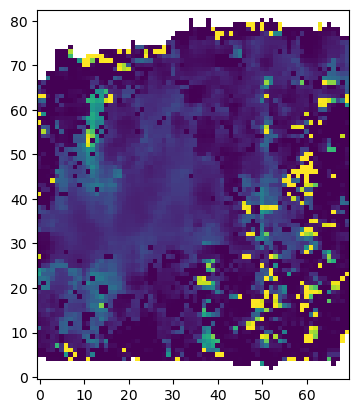

In [2]:
bla = np.load("output/4C1971.line.npz", allow_pickle=True)
plt.imshow(bla["emlsig"][None][0]["c1"]["[OIII]5007"].T, origin="lower")
img = bla["emlsig"][None][0]["c1"]["[OIII]5007"].T
img[18, 33]

In [3]:
def micron_to_redshift(wavelength, line):
    return wavelength/line - 1 

In [4]:
indir = "input/"
outdir = "output2/"
label = "4C1971"

if not os.path.exists(indir):
    os.makedirs(indir)
if not os.path.exists(outdir):
    os.makedirs(outdir)

logfile = os.path.join(indir, label+"-fitlog.txt")
infile = "4C1971_wo_continuum.fits"

# 
q3di = q3din(infile, label, outdir=outdir, logfile=logfile)
q3di.argsreadcube = {"wmapext": True}
cube = q3di.load_cube()
q3di.name = label
q3di.zsys_gas = 3.5892
q3di.fitrange = [2.15, 2.4]

#
lines = ['Hbeta', '[OIII]4959', '[OIII]5007']
line_wavelengths = [4861, 4959, 5007]
q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=2, checkcomp=False)
q3di.siglim_gas = np.array([40., 2000.])
q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
# q3di.argslinefit['method'] = 'leastsq'
q3di.argslinefit['method'] = 'least_squares'
q3di.argslinefit['ftol'] = 1.e-8
q3di.argslinefit['gtol'] = 1.e-8
q3di.argslinefit['xtol'] = 1.e-8
q3di.argslinefit['x_scale'] = 'jac'
q3di.argslinefit['tr_solver'] = 'lsmr'
q3di.argscheckcomp['sigcut'] = 3.
q3di.argscheckcomp['ignore']= ['Hbeta']

# 1 gauss data
previous_data = np.load("output/4C1971.line.npz", allow_pickle=True)

for i, w in zip(lines, line_wavelengths):
    init_val = micron_to_redshift(previous_data["emlwav"][None][0]["c1"][i], w)
    q3di.zinit_gas[i][:,:,0][~np.isnan(init_val)] = init_val[~np.isnan(init_val)]
    init_sig = np.clip(previous_data["emlsig"][None][0]["c1"][i], *q3di.siglim_gas)
    q3di.siginit_gas[i][:,:,0][~np.isnan(init_sig)] = init_sig[~np.isnan(init_sig)]

np.save(os.path.join(indir, "q3di2.npy"), q3di)

Cube: No wavelength units in header; using micron
Size of data cube: [ 70 , 83 , 3815 ]
Wavelength range: [ 1.660198 , 3.170542 ]  micron
Input flux units:  MJy/sr
Input wave units:  micron
Output flux units:  erg/s/cm2/micron
Output wave units:  micron
NB: q3dfit uses output units for internal calculations.


In [11]:
for j in range(2-1):
    print(j)

0


In [6]:
# run fit
filename_q3di = "input/q3di2.npy"
cols, rows = 13, 74
from q3dfit.q3df import q3dfit
q3dfit(filename_q3di, cols, rows, quiet=False, onefit=True)

Core 1: # spaxels fit=1
[col,row]=[13,74] out of [70,83]
FITLOOP: First call to FITSPEC
FITLOOP: Setting 3.000000 points from zero/inf flux or neg/zero/inf error to np.nan
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.8037e-32                                    0.00e+00    
`gtol` termination condition is satisfied.
Function evaluations 1, initial cost 4.8037e-32, final cost 4.8037e-32, first-order optimality 0.00e+00.
[[Model]]
    (((((Model(manygauss, prefix='Hbeta_0_', SPECRES='<q3dfit.spectConvol.spectConvol object at 0x7fc18c8bd190>') + Model(manygauss, prefix='Hbeta_1_', SPECRES='<q3dfit.spectConvol.spectConvol object at 0x7fc18c8bd190>')) + Model(manygauss, prefix='lbOIIIrb4959_0_', SPECRES='<q3dfit.spectConvol.spectConvol object at 0x7fc18c8bd190>')) + Model(manygauss, prefix='lbOIIIrb4959_1_', SPECRES='<q3dfit.spectConvol.spectConvol object at 0x7fc18c8bd190>')) + Model(manygauss, prefix='lbOIIIrb5

In [26]:
# run fit
filename_q3di = "input/q3di2.npy"
cols, rows = None, None
from q3dfit.q3df import q3dfit
q3dfit(filename_q3di, cols, rows, quiet=False, ncores=22, nocrash=True, onefit=True)

Core 1: # spaxels fit=264
Core 3: # spaxels fit=264
Core 19: # spaxels fit=264
Core 7: # spaxels fit=264
Core 14: # spaxels fit=264
Core 2: # spaxels fit=264
Core 4: # spaxels fit=264
Core 12: # spaxels fit=264
Core 11: # spaxels fit=265
Core 8: # spaxels fit=264
Core 21: # spaxels fit=264
Core 13: # spaxels fit=264
Core 10: # spaxels fit=264
Core 17: # spaxels fit=264
Core 18: # spaxels fit=264
Core 16: # spaxels fit=264Core 20: # spaxels fit=264

Core 22: # spaxels fit=265
Core 6: # spaxels fit=264
Core 15: # spaxels fit=264
Core 5: # spaxels fit=264
Core 9: # spaxels fit=264
